# Uplift Promotions Model
- Justin Wall, Analytics Consultant, BlueWing Air

---
## The Ask:
1. a model that tells us who actually needs the nudge, versus who's a lost cause, a sure thing already, or actively better off left alone.

2. a targeting list plus a read on the net revenue impact of only sending codes to the right people, versus blasting everyone like we do today.

## Load Data

In [1]:
import pandas as pd

df = pd.read_csv('../data/bluewing_air_promo_uplift.csv')

print(df.shape)
print('-------------------------------')
print(df.dtypes)
print('-------------------------------')
print(df.head())
print('-------------------------------')
print(df.describe())
print('-------------------------------')
print(df.groupby('treatment').agg({'converted': ['mean', 'sum']}))
print('-------------------------------')
print(df.groupby('treatment').agg({'customer_id': ['nunique']}))

(20000, 14)
-------------------------------
customer_id                    str
tenure_months                int64
loyalty_tier                   str
bookings_last_12mo           int64
days_since_last_booking    float64
avg_fare_last_year         float64
email_engagement_score     float64
treatment                    int64
converted                    int64
booking_revenue            float64
true_p_control             float64
true_p_treat               float64
true_uplift                float64
true_segment                   str
dtype: object
-------------------------------
  customer_id  tenure_months loyalty_tier  bookings_last_12mo  \
0  CUST000000              8       Silver                   3   
1  CUST000001             66       Silver                   1   
2  CUST000002             55        Basic                   0   
3  CUST000003             37        Basic                   1   
4  CUST000004             37        Basic                   2   

   days_since_last_booking  a

***
### **Notes**:
Campaign-level data, 20_000 customers, 2 treatment groups, conversion, loyalty tiers, Email Enagement Score, RFM
***

## Data Alignment - Business

#### Balance Check

In [2]:
# Balance check
feature_cols = ['tenure_months', 'bookings_last_12mo', 'days_since_last_booking',
                'avg_fare_last_year', 'email_engagement_score']

# side-by-side means by arm - should look nearly identical if randomization worked
balance = df.groupby('treatment')[feature_cols].mean().T
balance = balance.rename(columns={'treatment':'feature'})
balance['pct_diff'] = (balance[1] - balance[0]) / balance[0] * 100
balance = balance.rename(columns={0: 'control', 1: 'treatment'})
balance['pct_diff'] = balance['pct_diff'].round(2)
balance['pct_diff'] = balance['pct_diff'].astype(str) + '%'
balance = balance.reset_index().rename(columns={'index': 'feature'})
balance['control'] = balance['control'].round(2)
balance['treatment'] = balance['treatment'].round(2)
balance = balance[['feature', 'control', 'treatment', 'pct_diff']]
print(balance)

print('\n')
print('-------------------------------')
print('\n')

# loyalty_tier is categorical - check mix instead of mean
crosstab = pd.crosstab(df['loyalty_tier'], df['treatment'], normalize='columns')
crosstab = crosstab.rename(columns={0: 'control', 1: 'treatment'})
crosstab['control'] = (crosstab['control'] * 100).round(2).astype(str) + '%'
crosstab['treatment'] = (crosstab['treatment'] * 100).round(2).astype(str) + '%'
crosstab['diff'] = (crosstab['treatment'].str.rstrip('%').astype(float) - crosstab['control'].str.rstrip('%').astype(float)).round(2).astype(str) + '%'
print(crosstab)

treatment                  feature  control  treatment pct_diff
0                    tenure_months    42.16      42.25    0.21%
1               bookings_last_12mo     1.61       1.63    1.33%
2          days_since_last_booking    91.76      90.05   -1.87%
3               avg_fare_last_year   200.11     200.61    0.25%
4           email_engagement_score     0.45       0.45    0.01%


-------------------------------


treatment    control treatment    diff
loyalty_tier                          
Basic         59.59%    58.74%  -0.85%
Gold           9.26%    10.55%   1.29%
Silver        31.15%    30.71%  -0.44%


Randomization worked well here, no differences too large. Will still check the SMD for each feature for true balance.

#### SMD

In [3]:
# Standardized Mean Difference
# Convention for reading it:
# |SMD| < 0.1 = well balanced, 
# 0.1-0.25 = mild imbalance worth a mention, 
# >0.25 = actually worth investigating.
    
import numpy as np

def smd(treated, control):
    mean_diff = treated.mean() - control.mean()
    pooled_sd = np.sqrt((treated.var() + control.var()) / 2)
    return mean_diff / pooled_sd

balance = pd.DataFrame({
    'smd': [smd(df.loc[df.treatment==1, col], df.loc[df.treatment==0, col]) for col in feature_cols]
}, index=feature_cols)
balance['result'] = balance['smd'].apply(lambda x: 'well balanced' if abs(x) < 0.1 else ('mild imbalance' if abs(x) < 0.25 else 'worth investigating'))
print(balance)

                              smd         result
tenure_months            0.003609  well balanced
bookings_last_12mo       0.014332  well balanced
days_since_last_booking -0.018793  well balanced
avg_fare_last_year       0.008757  well balanced
email_engagement_score   0.000303  well balanced


In [4]:
# for tier in df['loyalty_tier'].unique():
#     p_t = (df.loc[df.treatment==1, 'loyalty_tier'] == tier).mean()
#     p_c = (df.loc[df.treatment==0, 'loyalty_tier'] == tier).mean()
#     smd_tier = (p_t - p_c) / np.sqrt((p_t*(1-p_t) + p_c*(1-p_c)) / 2)
#     print(f'{tier}: SMD = {smd_tier:.3f}')

All features below 0.05, so we can be sure the groups were randomized and balanced properly, no known confounding variables.

#### Aggregate Lift

In [5]:
# Aggregate lift

from statsmodels.stats.proportion import proportions_ztest

conv_control = df.loc[df['treatment'] == 0, 'converted']
conv_treat = df.loc[df['treatment'] == 1, 'converted']

n_control, n_treat = len(conv_control), len(conv_treat)
x_control, x_treat = conv_control.sum(), conv_treat.sum()

rate_control = x_control / n_control
rate_treat = x_treat / n_treat
abs_lift = rate_treat - rate_control
rel_lift = abs_lift / rate_control * 100

stat, pval = proportions_ztest([x_treat, x_control], [n_treat, n_control])

print(f"Control: {rate_control:.3%}  |  Treatment: {rate_treat:.3%}")
print(f"Absolute lift: {abs_lift:.3%}  |  Relative lift: {rel_lift:.1f}%")
print(f"z-stat: {stat:.2f}  |  p-value: {pval:.4f}")

Control: 20.905%  |  Treatment: 25.698%
Absolute lift: 4.793%  |  Relative lift: 22.9%
z-stat: 8.02  |  p-value: 0.0000


Treatment nearly 5pp higher than control. Proof of lift!

Text(0.5, 1.0, 'BlueWing Air Promo: Conversion Rate by Arm')

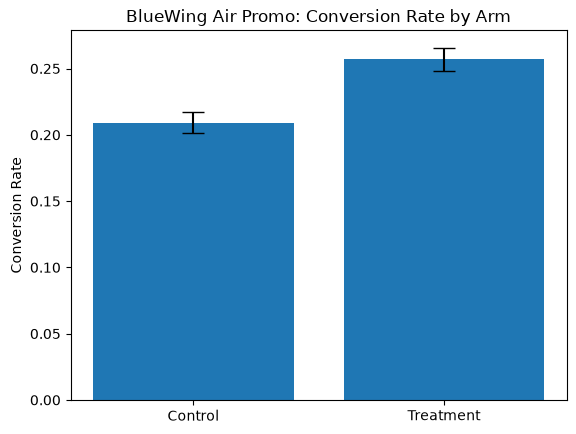

In [6]:
# Conversion rate by arm with error bars
import matplotlib.pyplot as plt

rates = [rate_control, rate_treat]
# 95% CI half-width for each proportion
ci = [1.96 * np.sqrt(r*(1-r)/n) for r, n in zip(rates, [n_control, n_treat])]

plt.bar(['Control', 'Treatment'], rates, yerr=ci, capsize=8)
plt.ylabel('Conversion Rate')
plt.title('BlueWing Air Promo: Conversion Rate by Arm')

#### Total Promo Cost

In [7]:
promo_cost = (df[df.treatment==1]['converted'] * df[df.treatment==1]['avg_fare_last_year'] * 0.15).sum()
incremental_bookings = (rate_treat - rate_control) * n_treat
incremental_revenue = incremental_bookings * df['avg_fare_last_year'].mean()
print(f"Discount cost from blanket send: ${promo_cost:,.0f}")
print(f"Estimated incremental revenue from lift: ${incremental_revenue:,.0f}")

Discount cost from blanket send: $78,941
Estimated incremental revenue from lift: $95,958


The campaign cost $78k in discounts and brought in an incremental $95k in revenue. Not all of these discounts went to people who needed them, some would have purchased anyway.

***
### **Notes**:
Treatment: 25.7% Conversion Rate

Control: 20.9% Conversion Rate

Lift: 4.8% absolute, 22.9% relative

Cost: $79k

Incremental Revenue: $96k
***

## Data Alignment - Technical

In [8]:
df.head()

,customer_id,tenure_months,loyalty_tier,bookings_last_12mo,days_since_last_booking,avg_fare_last_year,email_engagement_score,treatment,converted,booking_revenue,true_p_control,true_p_treat,true_uplift,true_segment
0,CUST000000,8,Silver,3,29.3,219.97,0.604,1,0,0.0,0.2700,0.2826,0.0126,lost_cause
1,CUST000001,66,Silver,1,252.9,265.71,0.389,0,0,0.0,0.0250,0.0100,-0.0314,lost_cause
2,CUST000002,55,Basic,0,487.7,264.89,0.313,0,0,0.0,0.0049,0.0100,-0.0145,lost_cause
3,CUST000003,37,Basic,1,121.2,124.57,0.253,0,0,0.0,0.0738,0.1174,0.0436,lost_cause
4,CUST000004,37,Basic,2,89.5,170.31,0.472,1,0,0.0,0.0829,0.1533,0.0704,persuadable


In [9]:
grouped = df.groupby('loyalty_tier').agg({'converted': ['mean','sum', 'count']})
grouped

converted             
                  mean   sum  count
loyalty_tier                       
Basic         0.174089  2060  11833
Gold          0.390207   773   1981
Silver        0.295344  1827   6186

In [10]:
df['loyalty_tier_basic'] = (df['loyalty_tier'] == 'Basic').astype(int)
df['loyalty_tier_silver'] = (df['loyalty_tier'] == 'Silver').astype(int)
df['loyalty_tier_gold'] = (df['loyalty_tier'] == 'Gold').astype(int)
print(df[['loyalty_tier', 'loyalty_tier_basic', 'loyalty_tier_silver', 'loyalty_tier_gold']].head(20))

   loyalty_tier  loyalty_tier_basic  loyalty_tier_silver  loyalty_tier_gold
0        Silver                   0                    1                  0
1        Silver                   0                    1                  0
2         Basic                   1                    0                  0
3         Basic                   1                    0                  0
4         Basic                   1                    0                  0
5         Basic                   1                    0                  0
6         Basic                   1                    0                  0
7          Gold                   0                    0                  1
8         Basic                   1                    0                  0
9         Basic                   1                    0                  0
10       Silver                   0                    1                  0
11        Basic                   1                    0                  0
12        Ba

***
### **Notes**:
Literally just binarized loyalty tier.
***

## Uplift Modeling

In [11]:
df.columns.to_list()

['customer_id',
 'tenure_months',
 'loyalty_tier',
 'bookings_last_12mo',
 'days_since_last_booking',
 'avg_fare_last_year',
 'email_engagement_score',
 'treatment',
 'converted',
 'booking_revenue',
 'true_p_control',
 'true_p_treat',
 'true_uplift',
 'true_segment',
 'loyalty_tier_basic',
 'loyalty_tier_silver',
 'loyalty_tier_gold']

In [12]:
# Step 0: Split Treatment & Control groups, split train & test, set features

from sklearn.model_selection import train_test_split

control = df.loc[df['treatment'] == 0]
treated = df.loc[df['treatment'] == 1]

converted = df['converted']

treatment = df['treatment']

booking_revenue = df['booking_revenue']

X = df[['tenure_months', 'loyalty_tier_silver', 'loyalty_tier_gold', 'bookings_last_12mo', 
        'days_since_last_booking', 'avg_fare_last_year', 'email_engagement_score']] 

X_train, X_test, w_train, w_test, y_train, y_test, rev_train, rev_test = train_test_split(
    X, treatment, converted, booking_revenue, test_size=0.3, random_state=42
)
e = 0.5  # known propensity - it's a real 50/50 RCT, don't fit a propensity model

In [13]:
# Step 1: Create results dataframe for post-modeling comparisons & validation

results = X_test.copy()
results['y'] = y_test # your observed outcome
results['w'] = w_test # your observed treatment assignment
results['revenue'] = rev_test # your observed revenue

# each method below just adds one column here, e.g. results['tau_S'], results['tau_T'], etc.

In [14]:
# Step 2: S/T/X/R-learner + Doubly Robust — one loop, since they share an API

from causalml.inference.meta import BaseSLearner, BaseTLearner, BaseXLearner, BaseRLearner, BaseDRLearner
from xgboost import XGBRegressor



s = BaseSLearner(learner=XGBRegressor())
t = BaseTLearner(learner=XGBRegressor())
x = BaseXLearner(learner=XGBRegressor())
r = BaseRLearner(learner=XGBRegressor())
dr = BaseDRLearner(learner=XGBRegressor())

s.fit(X_train.values, w_train.values, y_train.values)
t.fit(X_train.values, w_train.values, y_train.values)
x.fit(X_train.values, w_train.values, y_train.values)
r.fit(X_train.values, w_train.values, y_train.values)
# dr.fit(X_train.values, w_train.values, y_train.values) 
e_array = np.full(len(X_train), 0.5)
dr.fit(X_train.values, w_train.values, y_train.values, p=e_array)

results[f'tau_S'] = s.predict(X_test.values)
results[f'tau_T'] = t.predict(X_test.values)
results[f'tau_X'] = x.predict(X_test.values)
results[f'tau_R'] = r.predict(X_test.values)
# results[f'tau_DR'] = dr.predict(X_test.values)
e_array_test = np.full(len(X_test), 0.5)
results['tau_DR'] = dr.predict(X_test.values, p=e_array_test)

c:\Users\wallj\DS_Projects\MarketingScience\uplift_env\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\wallj\DS_Projects\MarketingScience\uplift_env\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\wallj\DS_Projects\MarketingScience\uplift_env\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\wallj\DS_Projects\MarketingScience\uplift_env\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\wallj\DS_Projects\MarketingScience\uplift_env\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the 

In [15]:
# Step 3: Causal forest with intervals

from econml.dml import CausalForestDML
cf = CausalForestDML()
cf.fit(y_train, w_train, X=X_train)
results['tau_CF'] = cf.effect(X_test)

In [16]:
# Step 4: Uplift trees with string-labels

from causalml.inference.tree import UpliftRandomForestClassifier

w_train_str = w_train.map({0: 'control', 1: 'treatment1'})
uplift_rf = UpliftRandomForestClassifier(control_name='control')
uplift_rf.fit(X_train.values, treatment=w_train_str.values, y=y_train.values)
results.loc[:, 'tau_UT'] = uplift_rf.predict(X_test.values)

Failed to import duecredit due to No module named 'duecredit'
c:\Users\wallj\DS_Projects\MarketingScience\uplift_env\Lib\site-packages\sklearn\utils\_testing.py:147: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  return fn(*args, **kwargs)
c:\Users\wallj\DS_Projects\MarketingScience\uplift_env\Lib\site-packages\sklearn\utils\_testing.py:147: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to

In [17]:
# Policy learning — the capstone

from econml.policy import PolicyTree
policy = PolicyTree(max_depth=3)
policy.fit(X_train, cf.effect(X_train))  # feed in your most-trusted CATE (probably causal forest)
recommended_treat = policy.predict(X_test)
# backtest: sum(revenue where recommended_treat matches actual w) vs. blanket-treat-everyone revenue

***
### **Notes**:
- S
- T
- X
- R
- DR
- CF
- UT
***

## Uplift Validation

### Validation 1: Value-Based Backtest
- The only validation method here that measures dollars and not ranking. Sort by predicted tau & compute the ipw-corrected net revenue at several targeting depths.

In [18]:
# e = 0.5
# for pct in [0.1, 0.2, 0.3, 0.4, 0.5]:
#     top_k = results.nlargest(int(len(results) * pct), 'tau_CF')
#     # IPW-corrected: reweight observed revenue by 1/propensity of the arm each customer landed in
#     weight = np.where(top_k['w'] == 1, 1/e, 1/(1-e))
#     value = (top_k['revenue'] * weight * top_k['w']).sum() / len(results)  # revenue attributable when treated

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

e = 0.5  # known propensity

def policy_value(df, treat_mask):
    """
    Unbiased IPW estimate of average per-customer net revenue under a policy
    that treats customers where treat_mask==True and leaves the rest alone.
    Only uses each customer's actually-observed arm.
    """
    treated_match = treat_mask & (df['w'] == 1)
    control_match = (~treat_mask) & (df['w'] == 0)

    treated_value = (df.loc[treated_match, 'revenue'] / e).sum()
    control_value = (df.loc[control_match, 'revenue'] / (1 - e)).sum()

    return (treated_value + control_value) / len(df)

In [20]:
tau_cols = ['tau_S', 'tau_T', 'tau_X', 'tau_R', 'tau_DR', 'tau_CF', 'tau_UT']
depths = np.arange(0.05, 1.01, 0.05)  # 5% to 100%

curves = {}
for col in tau_cols:
    ranked = results.sort_values(col, ascending=False)
    values = []
    for pct in depths:
        n_treat = int(len(results) * pct)
        treat_mask = results.index.isin(ranked.index[:n_treat])
        values.append(policy_value(results, treat_mask))
    curves[col] = values

# reference baselines
blanket_value = policy_value(results, pd.Series(True, index=results.index))
none_value = policy_value(results, pd.Series(False, index=results.index))

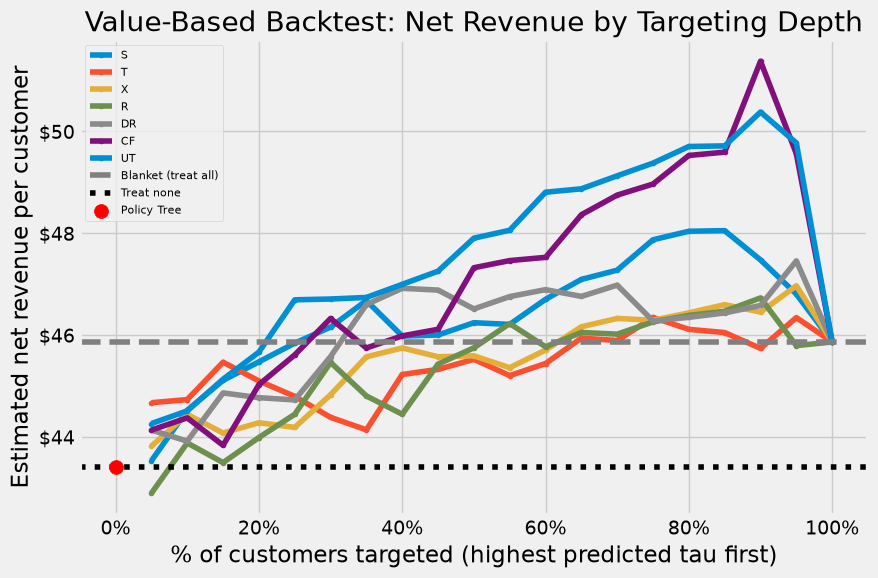

In [30]:
plt.figure(figsize=(9, 6))
for col, values in curves.items():
    plt.plot(depths * 100, values, marker='o', markersize=3, label=col.replace('tau_', ''))

plt.axhline(blanket_value, color='gray', linestyle='--', label='Blanket (treat all)')
plt.axhline(none_value, color='black', linestyle=':', label='Treat none')

policy_treat_mask = pd.Series(policy.predict(X_test) == 1, index=results.index)
policy_depth = policy_treat_mask.mean() * 100
policy_val = policy_value(results, policy_treat_mask)

plt.scatter([policy_depth], [policy_val], color='red', s=100, zorder=5, label='Policy Tree')
plt.legend(loc='best', fontsize=8)

# Format axis (y in dollars, x in percentage)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}'))
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))


plt.xlabel('% of customers targeted (highest predicted tau first)')
plt.ylabel('Estimated net revenue per customer')
plt.title('Value-Based Backtest: Net Revenue by Targeting Depth')
plt.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()

In [22]:
summary = pd.DataFrame({
    col.replace('tau_', ''): {
        'peak_value': max(vals),
        'best_depth_%': depths[np.argmax(vals)] * 100
    }
    for col, vals in curves.items()
}).T.sort_values('peak_value', ascending=False)

print(summary)

    peak_value  best_depth_%
CF   51.379910          90.0
UT   50.381593          90.0
S    48.052463          85.0
DR   47.458620          95.0
X    46.969663          95.0
R    46.730957          90.0
T    46.347957          75.0


***
### **Notes**:
Eyeballing it here...
1. CF
2. UT
3. S
4. R
5. DR
6. X
7. T

Scores (The definitive ranking)
1. CF
2. UT
3. S
4. R
5. X
6. DR
7. T


Causal Forest & Uplift Trees have the highest peak value which means that is the highest net revenue per customer at any depth. They both recommend going 90% into the model for max revenue, which is more clearly stated by telling marketing to cut the bottom 10% since they're not our persuadable group.
***

### Validation 2: Transformed Outcome
- 

In [23]:
Z = results['y'] * (results['w'] - e) / (e * (1 - e))

proxy_summary = pd.DataFrame({
    col.replace('tau_', ''): {
        'proxy_mse': np.mean((results[col] - Z)**2),
        'corr_with_Z': np.corrcoef(results[col], Z)[0, 1]
    }
    for col in tau_cols
}).T.sort_values('proxy_mse')

print(proxy_summary)

    proxy_mse  corr_with_Z
UT   0.917945     0.065464
CF   0.920179     0.047138
S    0.925539     0.019682
X    0.946761     0.010591
DR   0.965930     0.019436
T    0.972959     0.016220
R    0.990059     0.006357


***
### **Notes**:
Literally just binarized loyalty tier.
***

### Validation 3: Qini Score
- Ranking across the entire population

tau_S     0.131090
tau_T     0.090059
tau_X     0.077380
tau_R     0.066011
tau_DR    0.113027
tau_CF    0.184374
tau_UT    0.214060
dtype: float64

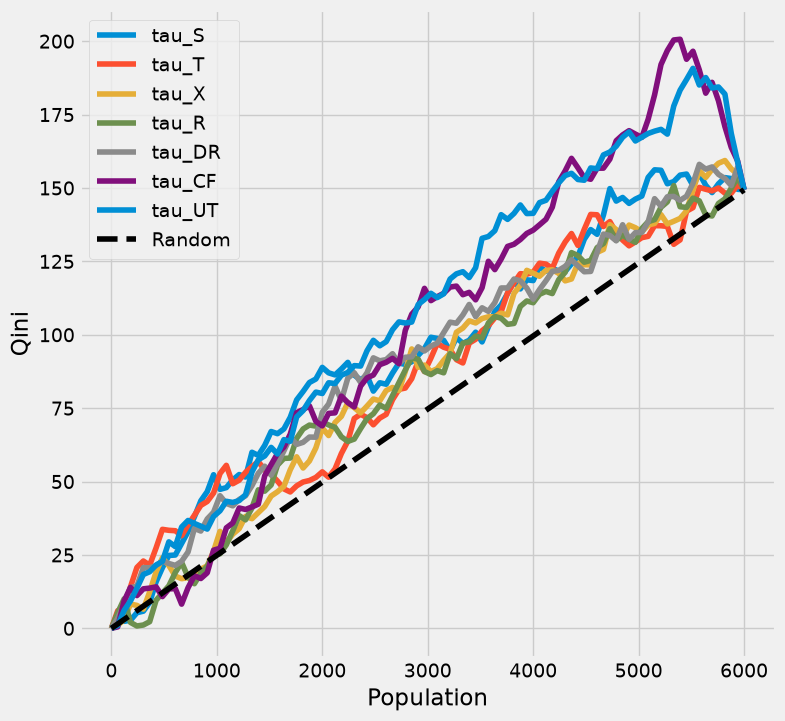

In [24]:
# Evaluation — one call covers all 7 CATE methods at once
from causalml.metrics import plot_qini, qini_score

tau_cols = [c for c in results.columns if c.startswith('tau_')]
eval_df = results[tau_cols + ['y', 'w']]
plot_qini(eval_df, outcome_col='y', treatment_col='w')  # overlays all curves in one plot
qini_score(eval_df, outcome_col='y', treatment_col='w')  # one score per method

***
### **Notes**:
Literally just binarized loyalty tier.
***

Eyeballing it here...
1. CF
2. UT
3. R
4. S
5. X
6. T
7. DR

Qini
1. UT
2. CF
3. R
4. S
5. T
6. X
7. DR

### Validation 4: Stability Check

In [25]:
from sklearn.utils import resample
from itertools import combinations

n_top = int(len(X_test) * 0.1)

# --- Causal Forest ---
cf_top_sets = []
for i in range(3):
    X_bs, w_bs, y_bs = resample(X_train, w_train, y_train, random_state=i)
    cf_bs = CausalForestDML()
    cf_bs.fit(y_bs, w_bs, X=X_bs)
    tau_bs = pd.Series(cf_bs.effect(X_test), index=X_test.index)
    cf_top_sets.append(set(tau_bs.nlargest(n_top).index))

cf_overlap = np.mean([len(a & b) / len(a | b) for a, b in combinations(cf_top_sets, 2)])
print(f'CF top-decile stability (Jaccard): {cf_overlap:.3f}')

# --- Uplift Tree ---
ut_top_sets = []
for i in range(3):
    X_bs, w_bs, y_bs = resample(X_train, w_train, y_train, random_state=i)
    w_bs_str = pd.Series(w_bs).map({0: 'control', 1: 'treatment1'})
    ut_bs = UpliftRandomForestClassifier(control_name='control')
    ut_bs.fit(X_bs.values, treatment=w_bs_str.values, y=y_bs.values)
    pred = ut_bs.predict(X_test.values)
    tau_bs = pd.Series(pred[:, 1] - pred[:, 0], index=X_test.index)
    ut_top_sets.append(set(tau_bs.nlargest(n_top).index))

ut_overlap = np.mean([len(a & b) / len(a | b) for a, b in combinations(ut_top_sets, 2)])
print(f'UT top-decile stability (Jaccard): {ut_overlap:.3f}')

CF top-decile stability (Jaccard): 0.117


c:\Users\wallj\DS_Projects\MarketingScience\uplift_env\Lib\site-packages\sklearn\utils\_testing.py:147: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  return fn(*args, **kwargs)
c:\Users\wallj\DS_Projects\MarketingScience\uplift_env\Lib\site-packages\sklearn\utils\_testing.py:147: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermed

IndexError: index 1 is out of bounds for axis 1 with size 1

***
### **Notes**:
Literally just binarized loyalty tier.
***

### Validation 5: Face Validity

In [26]:
for method in ['CF', 'UT']:
    top_decile = results.nlargest(int(len(results) * 0.1), f'tau_{method}')
    print(f'--- {method} top decile ---')
    print(top_decile[feature_cols].mean())
    print(top_decile['loyalty_tier'].value_counts(normalize=True))
    print()

--- CF top decile ---
tenure_months               38.620000
bookings_last_12mo           1.398333
days_since_last_booking     82.642833
avg_fare_last_year         187.573850
email_engagement_score       0.397990
dtype: float64


KeyError: 'loyalty_tier'

***
### **Notes**:
Literally just binarized loyalty tier.
***

***
### **Notes**:
Literally just binarized loyalty tier.
***

## Insights

#### "Are we giving away margin to people who'd book anyway?"

In [24]:
# Ground-truth segment check
results['true_uplift'] = df['true_uplift']   # your answer key
results['true_segment'] = df['true_segment'] # your answer key
results['true_segment'].value_counts()  # then eyeball, for your top CATE method, whether
# high tau_CF -> mostly true persuadables, negative tau_CF -> mostly true sleeping dogs

true_segment
lost_cause      2608
persuadable     2151
sure_thing       941
sleeping_dog     300
Name: count, dtype: int64

***
### **Notes**:
Literally just binarized loyalty tier.
***

#### "Are we training our best customers to expect discounts?"

***
### **Notes**:
Literally just binarized loyalty tier.
***

#### "Give me a targeting list and net revenue impact"

***
### **Notes**:
Literally just binarized loyalty tier.
***

#### Value decomposition

***
### **Notes**:
Literally just binarized loyalty tier.
***

#### Break-even framing

***
### **Notes**:
Literally just binarized loyalty tier.
***